In [2]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
congressional_voting_records = fetch_ucirepo(id=105) 
  
# data (as pandas dataframes) 
X = congressional_voting_records.data.features 
y = congressional_voting_records.data.targets 

In [46]:
X_t = X.replace('n',0).replace('y',1)
X_t

/tmp/ipykernel_3234522/1210561393.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_t = X.replace('n',0).replace('y',1)


,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa
0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0,0.0,1.0
1,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,NaN
2,NaN,1.0,1.0,NaN,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,NaN,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0
431,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
432,0.0,NaN,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0
433,0.0,0.0,0.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0.0,1.0,1.0,1.0,0.0,1.0


In [ ]:
from typing import List
import pandas as pd

def get_conditional_dist(X : pd.DataFrame,node_col : str,parents_cols : List[str]):
    node = X[node_col]
    node_unique = node.drop_duplicates().dropna().tolist()
    parents = X[parents_cols]
    unique_parents = parents.drop_duplicates().dropna()
    conditional_distribution = {
        'parent_names':parents_cols,
        'node_name':node_col,
        'node_values':node_unique,
    }
    for row in unique_parents.iterrows():
        mask = (parents==row[1]).T.all()
        masked = node[mask]
        dist = masked.value_counts()
        conditional_distribution[tuple(row[1].tolist())]=tuple(dist.tolist())
    return conditional_distribution

node_col = 'adoption-of-the-budget-resolution'
parents_cols = ['water-project-cost-sharing','handicapped-infants'] 

get_conditional_dist(X_t,node_col,parents_cols)

{'parent_names': ['water-project-cost-sharing', 'handicapped-infants'],
 'node_name': 'adoption-of-the-budget-resolution',
 'node_values': [0.0, 1.0],
 (1.0, 0.0): (63, 42),
 (1.0, 1.0): (67, 19),
 (0.0, 1.0): (71, 11),
 (0.0, 0.0): (60, 46)}

In [ ]:
import numpy as np

def compute_mi_2d(x, y, n_bins=None, bias_correct=True):
    """
    Compute mutual information between two 1D arrays using histograms (VECTORIZED).
    Includes optional Miller-Madow bias correction for finite sample sizes.
    
    Parameters:
    -----------
    x, y : np.ndarray
        Input arrays (must be same length)
    n_bins : int
        Number of bins for histogram estimation
    bias_correct : bool
        If True, apply Miller-Madow bias correction
    
    Returns:
    --------
    mi_normalized : float
        Mutual information normalized by H(Y), in range [0, 1]
    """
    # Remove NaN pairs
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Minimum samples for reliable estimation
    if n_bins is None:
        n_bins=int((min(len(np.unique(x_clean)),len(np.unique(y_clean)))/5)**0.5)
        n_bins=max(n_bins,2)
    min_samples = n_bins * n_bins * 5
    if len(x_clean) < min_samples:
        return 0.0
    
    n_samples = len(x_clean)
    
    # Joint histogram
    joint_counts, x_edges, y_edges = np.histogram2d(x_clean, y_clean, bins=n_bins)
    joint_prob = joint_counts / joint_counts.sum()
    
    # Marginal histograms (from joint, ensures consistency)
    px = joint_prob.sum(axis=1)  # shape (n_bins,)
    py = joint_prob.sum(axis=0)  # shape (n_bins,)
    
    # Vectorized MI computation
    eps = 1e-10
    
    # Create broadcasted outer product P(x)*P(y)
    px_py_outer = np.outer(px, py)  # shape (n_bins, n_bins)
    
    # Mask for valid cells (avoid log(0))
    valid_mask = (joint_prob > eps) & (px_py_outer > eps)
    
    # Compute raw MI in one vectorized operation
    if np.any(valid_mask):
        mi_raw = np.sum(joint_prob[valid_mask] * np.log(joint_prob[valid_mask] / px_py_outer[valid_mask]))
    else:
        mi_raw = 0.0
    
    # ============================================================
    # Miller-Madow Bias Correction
    # ============================================================
    # Formula: MI_corrected = MI_raw - (k-1)(m-1) / (2N)
    # Where k = non-empty X bins, m = non-empty Y bins, N = samples
    # ============================================================
    
    if bias_correct:
        # Count non-empty bins in each marginal
        k = np.sum(px > eps)  # non-empty X bins
        m = np.sum(py > eps)  # non-empty Y bins
        
        # Compute bias term
        bias = (k - 1) * (m - 1) / (2 * n_samples)
        
        # Apply correction (MI can't be negative)
        mi_corrected = max(0.0, mi_raw - bias)
    else:
        mi_corrected = mi_raw
    
    # ============================================================
    # Normalize by entropy of Y (target) to get [0, 1] scale
    # ============================================================
    
    py_valid = py[py > eps]
    if len(py_valid) > 0:
        entropy_y = -np.sum(py_valid * np.log(py_valid))
        if entropy_y > 1e-10:
            return mi_corrected / entropy_y
    
    return 0.0

In [172]:
features_mi = {}
for i in range(len(X_t.columns)):
    col_a = X_t.columns[i]
    feature = X_t[col_a]
    mi_list = []
    for j in range(i+1,len(X_t.columns)):
        col_b = X_t.columns[j]
        mi_list.append((col_b,compute_mi_2d(feature,X_t[col_b])))
    features_mi[col_a]=sorted(mi_list,key=lambda x:-x[1])[:3]

features_mi

{'handicapped-infants': [('education-spending',
   np.float64(0.14144463007913538)),
  ('physician-fee-freeze', np.float64(0.13918642622293484)),
  ('religious-groups-in-schools', np.float64(0.13033884182927388))],
 'water-project-cost-sharing': [('superfund-right-to-sue',
   np.float64(0.040648740010374274)),
  ('anti-satellite-test-ban', np.float64(0.032996438174402655)),
  ('mx-missile', np.float64(0.02902202178059419))],
 'adoption-of-the-budget-resolution': [('physician-fee-freeze',
   np.float64(0.4341201944396229)),
  ('aid-to-nicaraguan-contras', np.float64(0.4080333159158723)),
  ('education-spending', np.float64(0.35686789804460334))],
 'physician-fee-freeze': [('el-salvador-aid', np.float64(0.49772304805087003)),
  ('education-spending', np.float64(0.4166900205901196)),
  ('crime', np.float64(0.4035226049105097))],
 'el-salvador-aid': [('aid-to-nicaraguan-contras',
   np.float64(0.6468023316357697)),
  ('mx-missile', np.float64(0.5543322770572782)),
  ('crime', np.float64(0.

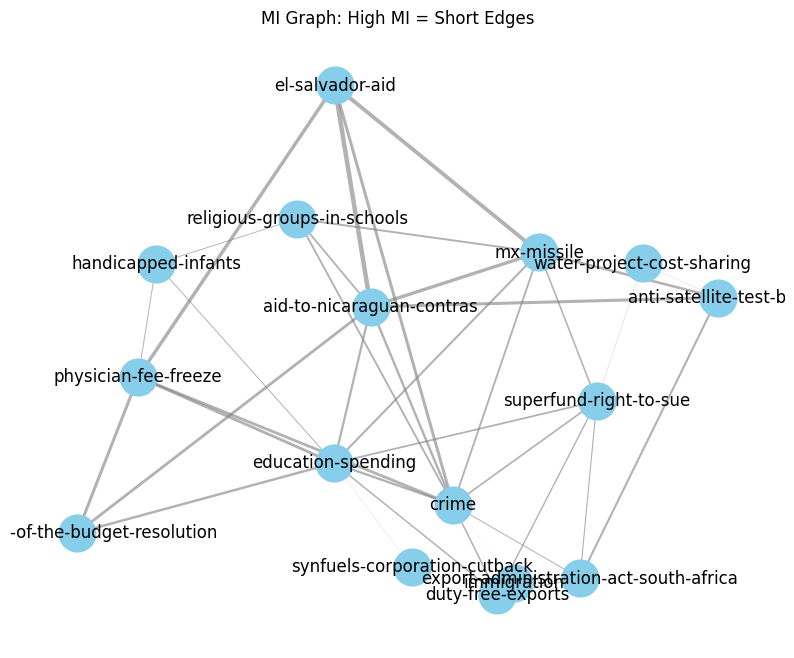

In [174]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Initialize and build graph as you did
G = nx.Graph()
G.add_nodes_from(X_t.columns)

for col_a, mi_list in features_mi.items():
    for col_b, mi_score in mi_list:
        if mi_score > 0.0:
            # We store the inverse of MI as 'distance'
            # Higher MI = Lower distance
            dist = 1.0 / (mi_score + 1e-6) 
            G.add_edge(col_a, col_b, weight=mi_score, distance=dist)

# Remove isolated nodes
isolated_nodes = [node for node, degree in G.degree() if degree == 0]
G.remove_nodes_from(isolated_nodes)

# 2. Layout with custom distances
# k is the optimal distance between nodes. 
# We use the 'distance' attribute to pull highly correlated features together.
pos = nx.spring_layout(G, weight='distance', seed=42)

# 3. Visualize
plt.figure(figsize=(10, 8))

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_labels(G, pos)

# Edge width remains proportional to MI
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

plt.title("MI Graph: High MI = Short Edges")
plt.axis('off')
plt.show()